In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import os

In [ ]:
# --- 1. Load and Inspect Data ---
# Use a raw string for the Windows file path.
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\data_raw.csv"
df = pd.read_csv(data_path)

In [ ]:
# Display the first few rows to verify the structure
print(df.head())

In [ ]:
# --- 2. Prepare the Labels ---
# Assuming the columns for emotions are named exactly as follows:
emotion_cols = ['happy', 'sad', 'disgusted', 'mad', 'scared', 'surprised', 'neutral']
# For single emotion classification, we pick the index of the column with the highest value (assumed to be 1)
labels = df[emotion_cols].values
# Get the class index for each sample
y = np.argmax(labels, axis=1)
# Convert to one-hot encoding for categorical crossentropy
y_cat = to_categorical(y, num_classes=len(emotion_cols))

In [ ]:
# --- 3. Prepare the Text Data ---
texts = df['text'].astype(str).tolist()  # ensure all texts are strings

# Set parameters for tokenization and padding
max_num_words = 10000  # maximum number of words to consider in the vocabulary
max_sequence_length = 100  # adjust based on your data (or use the maximum length in your dataset)
embedding_dim = 100  # size of the embedding vector

tokenizer = Tokenizer(num_words=max_num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print("Found %s unique tokens." % len(word_index))

# Pad sequences so that each input has the same length
X = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

In [ ]:
print("Loaded Word2Vec model with %s word vectors." % len(word2vec_model.key_to_index))


In [ ]:
from gensim.models import KeyedVectors

# Update the path to your pre-trained Word2Vec model (e.g., Google News vectors)
word2vec_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\GoogleNews-vectors-negative300.bin"

# Load the Word2Vec model (this may take some time)
word2vec_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
embedding_dim = 300  # Google News Word2Vec embeddings are 300-dimensional

print("Loaded Word2Vec model with %s word vectors." % len(word2vec_model.vocab))

# Create the embedding matrix using the Word2Vec embeddings
num_words = min(max_num_words, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= max_num_words:
        continue
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]


In [ ]:
# --- 4. Split Data into Training and Validation Sets ---
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42)

In [ ]:
model = Sequential()
model.add(Embedding(input_dim=num_words,
                    output_dim=embedding_dim,
                    input_length=max_sequence_length,
                    weights=[embedding_matrix],
                    trainable=False))  # Freeze the embeddings
model.add(Bidirectional(LSTM(128, dropout=0.1, recurrent_dropout=0.1)))
model.add(Dense(len(emotion_cols), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
]

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=60,
                    batch_size=32,
                    callbacks=callbacks)

In [ ]:
# --- 9. Error Analysis: Confusion Matrix and Classification Report ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict probabilities on the validation set and then convert to class labels
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_cols, yticklabels=emotion_cols)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Print the classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_cols))

In [ ]:
# --- 7. Save the Model (optional) ---
model.save("lstm_model_2.h5")

   Unnamed: 0                                               text  happy  sad  \
0           0                                    That game hurt.      0    1   
1           2     You do right, if you don't care then fuck 'em!      0    0   
2           3                                 Man I love reddit.      1    0   
3           4  [NAME] was nowhere near them, he was by the Fa...      0    0   
4           5  Right? Considering it’s such an important docu...      1    0   

   disgusted  mad  scared  surprised  neutral  \
0          0    0       0          0        0   
1          0    0       0          0        1   
2          0    0       0          0        0   
3          0    0       0          0        1   
4          0    0       0          0        0   

                                            POS_Tags  ... Sentiment  \
0  [('That', 'DT'), ('game', 'NN'), ('hurt', 'VBD...  ...  Negative   
1  [('You', 'PRP'), ('do', 'VBP'), ('right', 'RB'...  ...   Neutral   
2  [('Man',

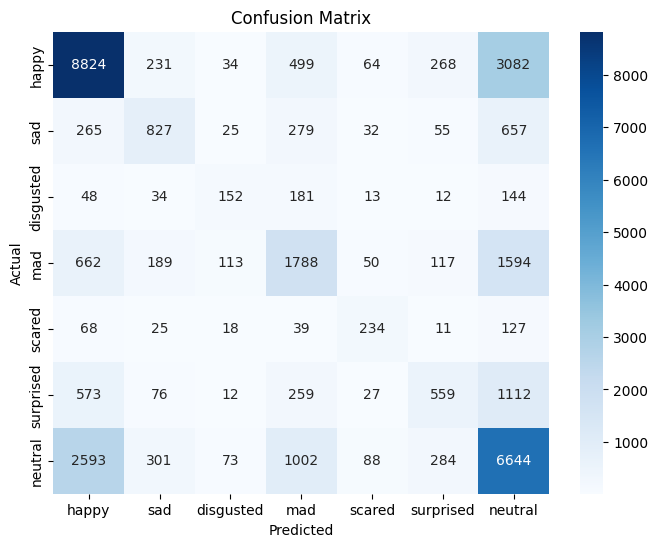

Classification Report:
              precision    recall  f1-score   support

       happy       0.68      0.68      0.68     13002
         sad       0.49      0.39      0.43      2140
   disgusted       0.36      0.26      0.30       584
         mad       0.44      0.40      0.42      4513
      scared       0.46      0.45      0.45       522
   surprised       0.43      0.21      0.28      2618
     neutral       0.50      0.60      0.55     10985

    accuracy                           0.55     34364
   macro avg       0.48      0.43      0.44     34364
weighted avg       0.55      0.55      0.55     34364



In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from gensim.models import KeyedVectors
import os

# --- 1. Load and Inspect Data ---
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\data_raw.csv"
df = pd.read_csv(data_path)
print(df.head())

# --- 2. Prepare the Labels ---
emotion_cols = ['happy', 'sad', 'disgusted', 'mad', 'scared', 'surprised', 'neutral']
labels = df[emotion_cols].values
y = np.argmax(labels, axis=1)
y_cat = to_categorical(y, num_classes=len(emotion_cols))

# --- 3. Prepare the Text Data ---
texts = df['text'].astype(str).tolist()
max_num_words = 10000
max_sequence_length = 100

tokenizer = Tokenizer(num_words=max_num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print("Found %s unique tokens." % len(word_index))
X = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

# --- 4. Load Pre-trained Word2Vec Embeddings ---
word2vec_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\GoogleNews-vectors-negative300.bin"  # Update this path accordingly
word2vec_model = KeyedVectors.load_word2vec_format(word2vec_path, binary=True)
embedding_dim = 300  # Google News Word2Vec embeddings are 300-dimensional

print("Loaded Word2Vec model with %s word vectors." % len(word2vec_model.key_to_index))

# Create the embedding matrix using the Word2Vec embeddings
num_words = min(max_num_words, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= max_num_words:
        continue
    if word in word2vec_model:
        embedding_matrix[i] = word2vec_model[word]

# --- 5. Split Data into Training and Validation Sets ---
X_train, X_val, y_train, y_val = train_test_split(X, y_cat, test_size=0.2, random_state=42)

# --- 6. Build the LSTM Model with Pre-trained Word2Vec Embeddings ---
model = Sequential()
model.add(Embedding(input_dim=num_words,
                    output_dim=embedding_dim,
                    input_length=max_sequence_length,
                    weights=[embedding_matrix],
                    trainable=False))  # Freeze embeddings
model.add(Bidirectional(LSTM(128, dropout=0.1, recurrent_dropout=0.1)))
model.add(Dense(len(emotion_cols), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# --- 7. Train the Model with Callbacks ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

epochs = 50
batch_size = 32
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model_word2vec.h5', monitor='val_loss', save_best_only=True)
]

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=epochs,
                    batch_size=batch_size,
                    callbacks=callbacks)

# --- 8. Error Analysis: Confusion Matrix and Visualizations ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_cols, yticklabels=emotion_cols)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_cols))
